In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt 
import sys
sys.path.append('..') 
from src.shapley_sampler import ShapleySampler
from src.samplers import RandomSampler, BaseSampler

In [2]:
def f(x):
    return x * 2 + 1

np.random.seed(42)
X = np.linspace(0,100,1000)
y = f(X)

noise = np.random.normal(0, 10, size=X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)
n_noise = 100
noise_idx = np.random.choice(np.arange(len(y_train)), replace=False, size=n_noise)
y_train[noise_idx] += noise[noise_idx]

In [3]:
full_model = HistGradientBoostingRegressor(max_iter=100)
full_model.fit(X_train, y_train)

no_sampler = BaseSampler()
random_sampler = RandomSampler(num_samples=100)
shapley_sampler = ShapleySampler(X_test, y_test, num_samples=100)

In [4]:
def train_and_evaluate(sampler, X_train, y_train, X_test, y_test, iterations=100):
    mse_test = []
    r2_test = []
    mse_train = []
    r2_train = []
    for i in range(iterations):
        X_sampled, y_sampled, weight = sampler(X_train, y_train, weight=np.ones_like(X_train))

        model = HistGradientBoostingRegressor(max_iter=i+1)
        model.fit(X_sampled, y_sampled)

        y_pred_test = model.predict(X_test)
        y_pred_train = model.predict(X_train)

        mse_test.append(mean_squared_error(y_test, y_pred_test))
        r2_test.append(r2_score(y_test, y_pred_test) * 100)

        mse_train.append(mean_squared_error(y_train, y_pred_train))
        r2_train.append(r2_score(y_train, y_pred_train) * 100)

    return mse_test, r2_test, mse_train, r2_train, weight

In [5]:
full_mse_test, full_r2_test, full_mse_train, full_r2_train, weight = train_and_evaluate(no_sampler, X_train, y_train, X_test, y_test, iterations=100)
random_mse_test, random_r2_test, random_mse_train, random_r2_train, _ = train_and_evaluate(random_sampler, X_train, y_train, X_test, y_test, iterations=100)

In [ ]:
shapley_mse_test, shapley_r2_test, shapley_mse_train, shapley_r2_train, _ = train_and_evaluate(shapley_sampler, X_train, y_train, X_test, y_test, iterations=100)

  0%|          | 0/100 [00:00<?, ?%/s]

d:\anac\Lib\site-packages\pydvl\parallel\backends\joblib.py:87: UserWarning: Cancellation of futures is not supported by the joblib backend
  warnings.warn(


  0%|          | 0/100 [00:00<?, ?%/s]

d:\anac\Lib\site-packages\pydvl\parallel\backends\joblib.py:87: UserWarning: Cancellation of futures is not supported by the joblib backend
  warnings.warn(


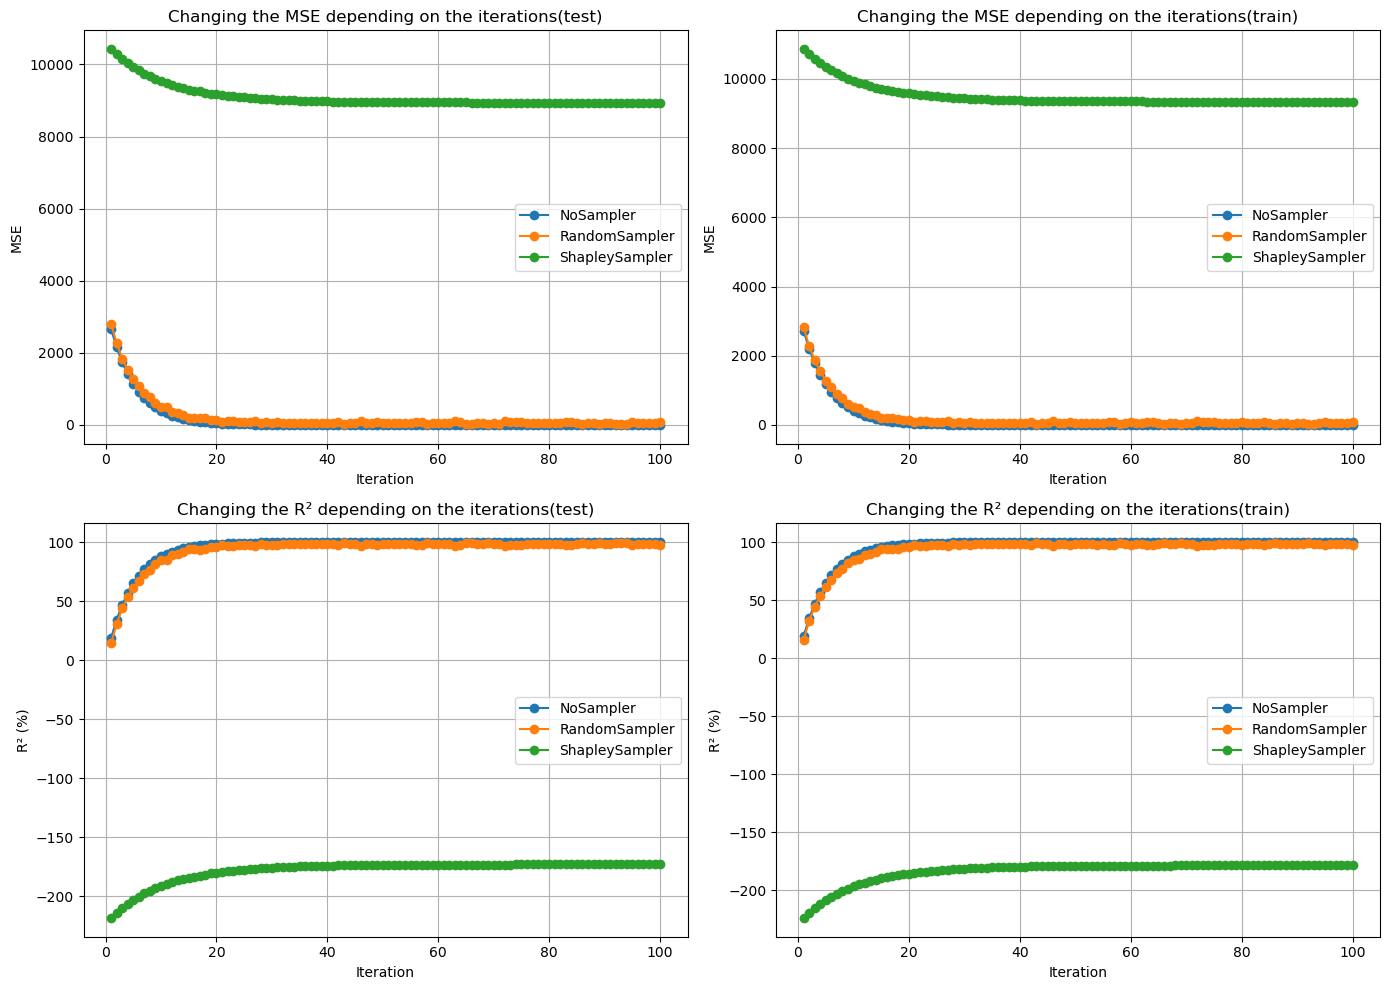

In [ ]:
# Построим графики
plt.figure(figsize=(14, 10))

# График MSE для теста
plt.subplot(2, 2, 1)
plt.plot(range(1, 101), full_mse_test, label="NoSampler", marker="o")
plt.plot(range(1, 101), random_mse_test, label="RandomSampler", marker="o")
plt.plot(range(1, 101), shapley_mse_test, label="ShapleySampler", marker="o")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Changing the MSE depending on the iterations(test)")
plt.legend()
plt.grid()

# График R² для теста 
plt.subplot(2, 2, 3)
plt.plot(range(1, 101), full_r2_test, label="NoSampler", marker="o")
plt.plot(range(1, 101), random_r2_test, label="RandomSampler", marker="o")
plt.plot(range(1, 101), shapley_r2_test, label="ShapleySampler", marker="o")
plt.xlabel("Iteration")
plt.ylabel("R² (%)")
plt.title("Changing the R² depending on the iterations(test)")
plt.legend()
plt.grid()

# График MSE для трейна
plt.subplot(2, 2, 2)
plt.plot(range(1, 101), full_mse_train, label="NoSampler", marker="o")
plt.plot(range(1, 101), random_mse_train, label="RandomSampler", marker="o")
plt.plot(range(1, 101), shapley_mse_train, label="ShapleySampler", marker="o")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Changing the MSE depending on the iterations(train)")
plt.legend()
plt.grid()

# График R² для трейна
plt.subplot(2, 2, 4)
plt.plot(range(1, 101), full_r2_train, label="NoSampler", marker="o")
plt.plot(range(1, 101), random_r2_train, label="RandomSampler", marker="o")
plt.plot(range(1, 101), shapley_r2_train, label="ShapleySampler", marker="o")
plt.xlabel("Iteration")
plt.ylabel("R² (%)")
plt.title("Changing the R² depending on the iterations(train)")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
pip install --upgrade numpy joblib scikit-learn pydvl